# 02 · When the t-Test Breaks

Notebook 01 established the rubric and showed the t-test passing it on data that satisfies its
assumptions. This notebook breaks those assumptions one at a time and measures what happens.

The Student t-test assumes two things:

1. both groups are **normally distributed**, and
2. the two groups have **equal variances**.

The second is the one almost nobody checks. Here is what it costs.

In [1]:
# Make the project importable whether this notebook is run from notebooks/ or the repo root.
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import numpy as np

from src.config import get_settings, save_results
from src.evaluation import derive_seed, name_key
from src.evaluation.calibration import pvalue_calibration
from src.evaluation.comparison import run_arena
from src.evaluation.false_positive import false_positive_rate, is_calibrated, is_inflated
from src.simulation.scenarios import base_scenarios
from src.tests.student import student_test
from src.tests.welch import welch_test
from src.visualisation import (
    plot_false_positive_rates,
    plot_pvalue_calibration,
    plot_rejection_rate_curve,
    plot_samples,
    save_figure,
)

settings = get_settings()
alpha, n_reps = settings.alpha, settings.reps.n_reps
# Seeds are derived from the scenario *name*, and with_effect() renames "x" to "x::null",
# so the null grid is built first and indexed by base name. Using the unsuffixed scenario
# here would silently measure the same condition on a different data stream.
null_grid = [s.with_effect(0.0) for s in base_scenarios(settings)]
scenarios = {s.name.split("::")[0]: s for s in null_grid}
figures: dict[str, str] = {}
tests = {"student": student_test, "welch": welch_test}

print(f"alpha={alpha}   replications per cell={n_reps:,}   mc_se near 0.05 = "
      f"{(0.05 * 0.95 / n_reps) ** 0.5:.4f}")


# The seed pair run_arena would use, so every number in this notebook is the *same*
# measurement as the corresponding grid cell rather than an independent one that happens
# to be close.
def seeds(scenario, test_name):
    return {
        "data_seed": derive_seed(settings.seed, name_key(scenario.name)),
        "test_seed": derive_seed(settings.seed, name_key(scenario.name), name_key(test_name)),
    }

alpha=0.05   replications per cell=10,000   mc_se near 0.05 = 0.0022


## The showpiece: unequal variances, unequal group sizes

A realistic setup. Group a is the large control arm — 100 users, standard deviation 1. Group b
is the small treatment arm — 15 users, standard deviation 4, because the treatment increased
both the level and the spread.

**Both populations have exactly the same mean.** There is nothing to find. Every "significant"
result below is a phantom.

n_a = 100, sd_a = 1.0
n_b = 15, sd_b = 4.0
true difference in means: 0.0  (the null is TRUE)


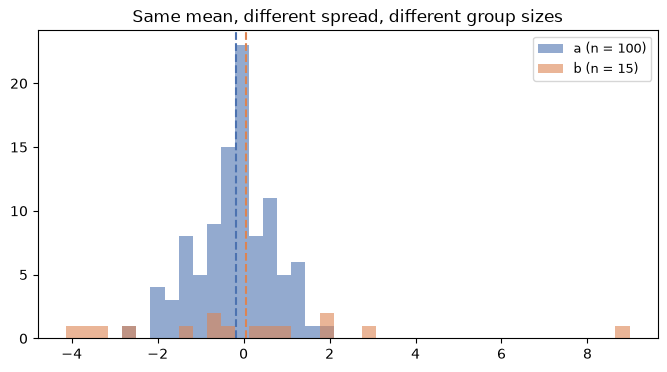

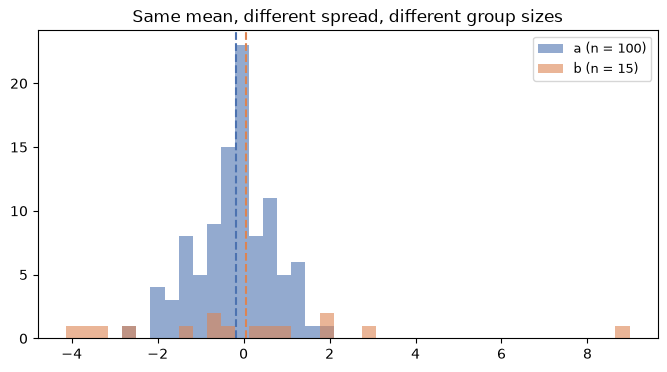

In [3]:
showpiece = scenarios["normal_unequal_var_unequal_n"]
print(f"n_a = {showpiece.n_a}, sd_a = {showpiece.sd_a}")
print(f"n_b = {showpiece.n_b}, sd_b = {showpiece.sd_b}")
print(f"true difference in means: {showpiece.true_mean_difference}  (the null is TRUE)")

a, b = showpiece.draw(np.random.default_rng(settings.notebooks.demo_seed))
fig = plot_samples(a, b, title="Same mean, different spread, different group sizes")
figures["showpiece_samples"] = save_figure(fig, "02_showpiece_samples")
fig

In [4]:
showpiece_rates = {}
for name, test_fn in tests.items():
    result = false_positive_rate(
        test_fn, showpiece, n_reps=n_reps, alpha=alpha, test_name=name,
        **seeds(showpiece, name),
    )
    showpiece_rates[name] = result
    verdict = "INFLATED" if is_inflated(result) else ("calibrated" if is_calibrated(result) else "off")
    print(
        f"{name:<8} false-positive rate {result.rate:.4f} ± {2 * result.mc_se:.4f}   "
        f"({result.rate / alpha:5.1f}× the promised {alpha})   {verdict}"
    )

student  false-positive rate 0.3753 ± 0.0097   (  7.5× the promised 0.05)   INFLATED


welch    false-positive rate 0.0477 ± 0.0043   (  1.0× the promised 0.05)   calibrated


That is the whole project in two lines.

The Student t-test, run on data where **nothing is going on**, reported a significant difference
far more often than the 5% it promises. Every one of those is a discovery that does not exist —
and there is no error, no warning, no diagnostic. Just a confident number.

Welch, which differs only in not assuming equal variances, sits on α.

### Why it happens

Student pools the two variances into one estimate, weighting by degrees of freedom. The large
group dominates the pool, so the pooled variance is close to group a's small variance — which
badly understates the true standard error of the difference. A too-small denominator makes the t
statistic too big, and borderline results get pushed over the line.

## Why nobody notices: the same variance ratio with equal group sizes

Change one thing — make the groups the same size, keeping the 4× variance ratio — and the error
almost vanishes. This is the honesty check, and it is why the failure is invisible in textbook
examples and in any comparison where the arms happen to be balanced.

In [5]:
balanced = scenarios["normal_unequal_var_equal_n"]
balanced_rates = {}
for name, test_fn in tests.items():
    result = false_positive_rate(
        test_fn, balanced, n_reps=n_reps, alpha=alpha, test_name=name,
        **seeds(balanced, name),
    )
    balanced_rates[name] = result
    print(
        f"{name:<8} false-positive rate {result.rate:.4f} ± {2 * result.mc_se:.4f}   "
        f"calibrated={is_calibrated(result)}"
    )
print()
print("Same variance ratio, balanced groups: Student is close to fine.")
print("The variance assumption only bites when the sample sizes are unequal too.")

student  false-positive rate 0.0550 ± 0.0046   calibrated=True


welch    false-positive rate 0.0524 ± 0.0045   calibrated=True

Same variance ratio, balanced groups: Student is close to fine.
The variance assumption only bites when the sample sizes are unequal too.


## The proof figure: p-values that are not uniform

Rejecting too often at one α is a symptom. The disease is that the p-values are not uniform, so
the number the test reports does not mean what it says at *any* threshold.

In [6]:
calibration = []
for scenario_name, tag in [
    ("normal_unequal_var_unequal_n", "broken"),
    ("normal_equal_var", "clean"),
]:
    for name, test_fn in tests.items():
        calibration.append(
            (
                tag,
                pvalue_calibration(
                    test_fn, scenarios[scenario_name], n_reps=n_reps, alpha=alpha,
                    test_name=name, **seeds(scenarios[scenario_name], name),
                ),
            )
        )

for tag, result in calibration:
    print(
        f"{tag:<7} {result.test:<8} KS distance from uniform {result.ks_statistic:.4f}   "
        f"uniform? {str(result.is_uniform()):<5}  rejection rate at α: {result.rejection_rate:.4f}"
    )

broken  student  KS distance from uniform 0.3723   uniform? False  rejection rate at α: 0.3753
broken  welch    KS distance from uniform 0.0067   uniform? True   rejection rate at α: 0.0477
clean   student  KS distance from uniform 0.0147   uniform? True   rejection rate at α: 0.0496
clean   welch    KS distance from uniform 0.0148   uniform? True   rejection rate at α: 0.0495


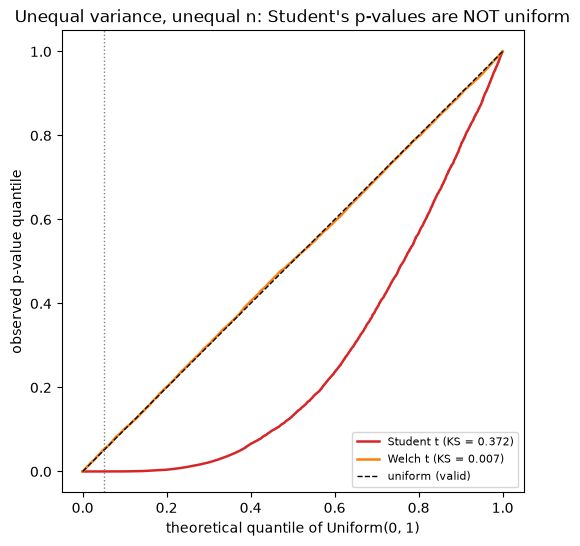

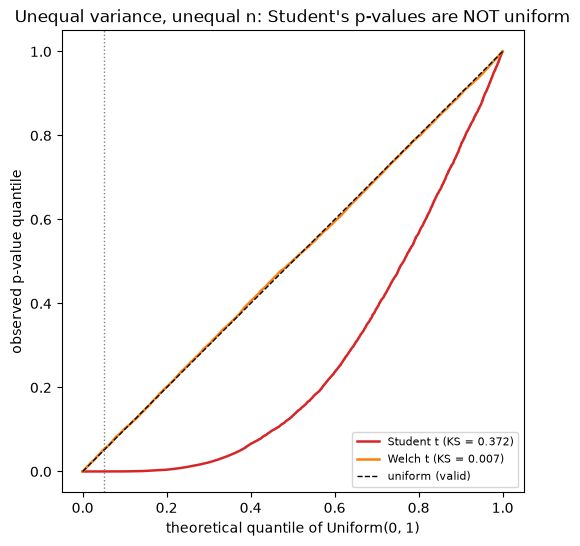

In [7]:
broken = [r for tag, r in calibration if tag == "broken"]
fig = plot_pvalue_calibration(broken, alpha=alpha)
fig.axes[0].set_title("Unequal variance, unequal n: Student's p-values are NOT uniform")
figures["calibration_broken"] = save_figure(fig, "02_calibration_broken")
fig

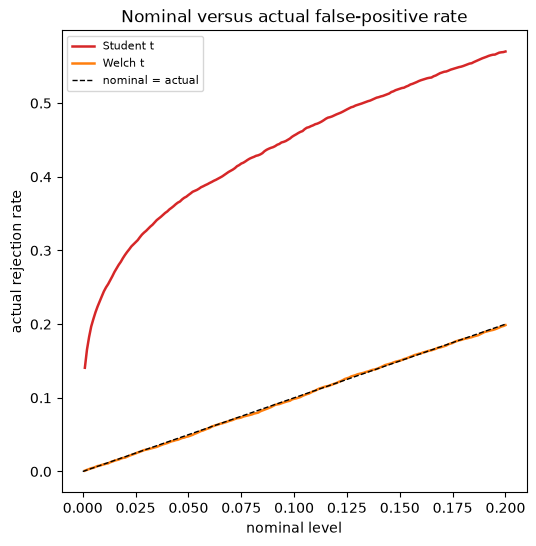

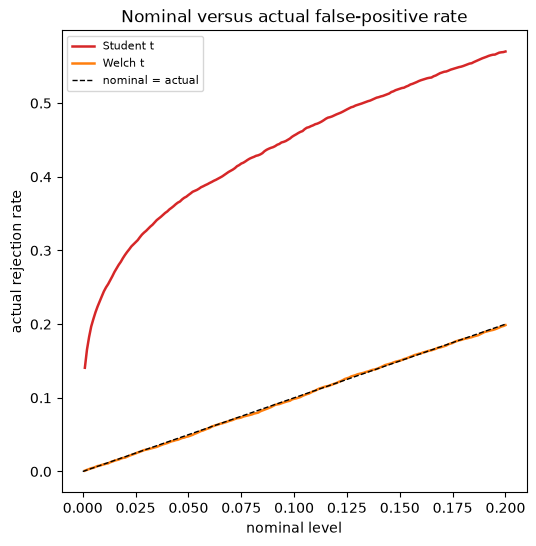

In [8]:
fig = plot_rejection_rate_curve(broken)
figures["rejection_rate_curve"] = save_figure(fig, "02_rejection_rate_curve")
fig

Read the second figure directly: pick any nominal level on the x-axis and the curve tells you
the rate you actually get. Ask Student for 1% and it gives you roughly a third. The Welch line
sits on the diagonal, which is what "the p-value means what it says" looks like.

## The other direction: skew and small samples

The variance failure inflates false positives. The second failure mode is the opposite — a test
that is *conservative*, quietly spending power it could have had.

Here are all the null conditions in the grid, for both t-tests at once.

In [9]:
grid_rates = run_arena(null_grid, tests=tests, settings=settings)
grid_rates.pivot(index="scenario", columns="test", values="reject_rate").round(4)

test,student,welch
scenario,,
contaminated_outliers::null,0.0432,0.0426
heavy_tailed::null,0.0459,0.0458
normal_equal_var::null,0.0496,0.0495
normal_unequal_var_equal_n::null,0.0550,0.0524
normal_unequal_var_unequal_n::null,0.3753,0.0477
skewed_extreme_unequal::null,0.1538,0.1767
skewed_small_n::null,0.0402,0.0372
skewed_unequal_n::null,0.0502,0.0897


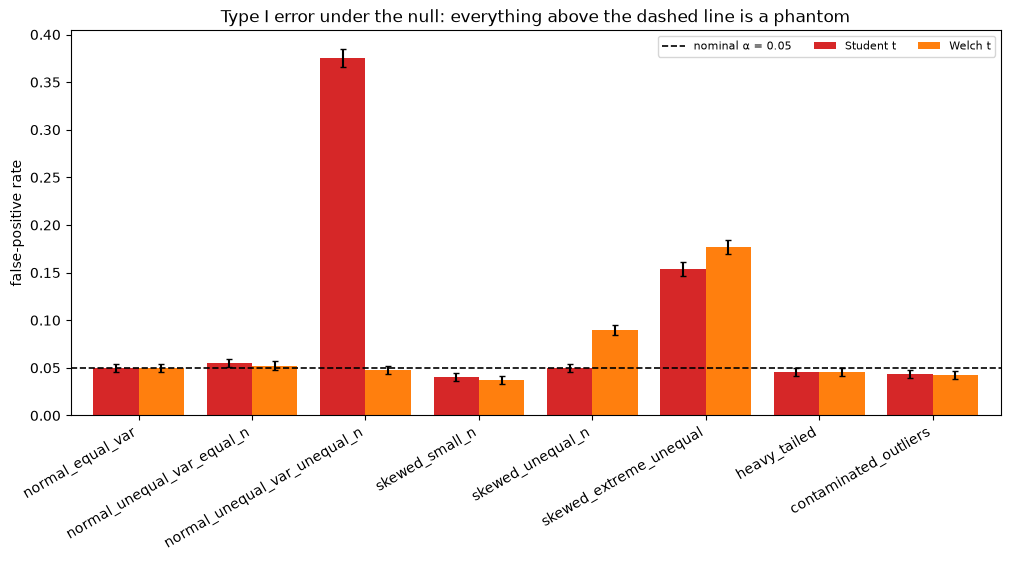

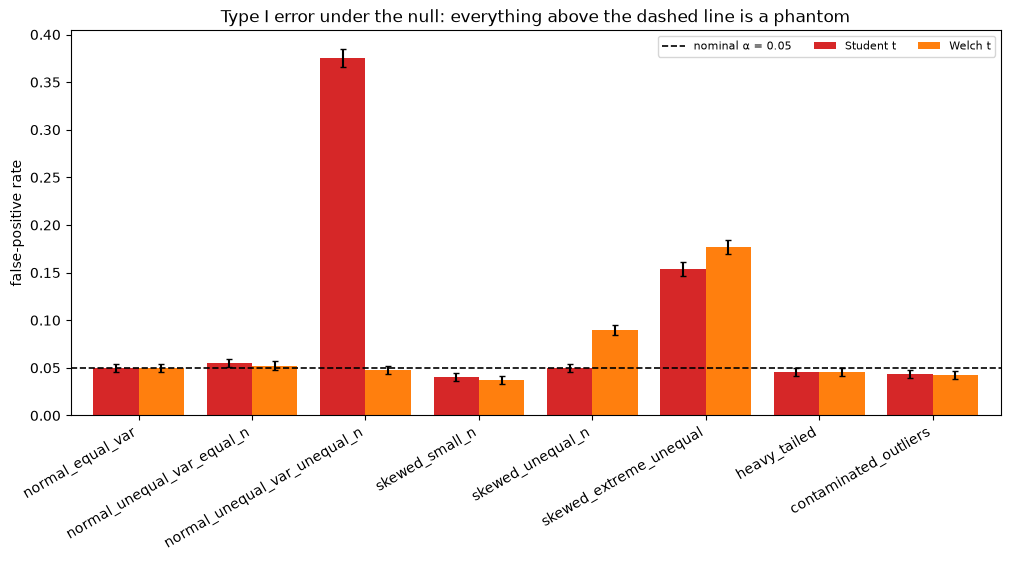

In [10]:
fig = plot_false_positive_rates(grid_rates, alpha=alpha)
figures["fpr_across_scenarios"] = save_figure(fig, "02_fpr_across_scenarios")
fig

Three separate stories in one figure:

- **`normal_unequal_var_unequal_n`** — Student explodes; Welch is fine.
- **`skewed_unequal_n`** — the reverse. Skewed data with unbalanced groups is where *Welch* runs
  above α while Student happens to be closer. Neither t-test is reliably safe here; they simply
  fail in different places.
- **`skewed_extreme_unequal`** — both fail badly. This is the limit case, kept in the grid on
  purpose. Notebook 04 shows that the assumption-free tests do better here but do not rescue it
  either. A project about overclaimed tests should not overclaim.

## What we have established

- Student's false-positive rate is several times α when the group with larger variance is the
  smaller group. Those results are phantoms and nothing warns you.
- The failure hides at equal sample sizes, which is why it is rarely noticed.
- Welch fixes that case and costs nothing.
- Welch is **not** universally safe: on skewed unbalanced data it is the one running hot.
- The diagnostic behind all of it is p-value uniformity.

Next: the tests that assume nothing about the shape at all.

In [11]:
summary = {
    "notebook": "02_when_the_t_test_breaks",
    "settings": {"profile": settings.profile, "alpha": alpha, "n_reps": n_reps,
                 "seed": settings.seed},
    "showpiece": {
        "scenario": showpiece.name,
        "n_a": showpiece.n_a, "n_b": showpiece.n_b,
        "sd_a": showpiece.sd_a, "sd_b": showpiece.sd_b,
        "true_mean_difference": showpiece.true_mean_difference,
        "false_positive_rates": {
            name: {
                "rate": r.rate, "mc_se": r.mc_se, "times_alpha": r.rate / alpha,
                "deviation_in_se": r.deviation_in_se(alpha), "inflated": is_inflated(r),
            }
            for name, r in showpiece_rates.items()
        },
    },
    "balanced_control": {
        "scenario": balanced.name,
        "false_positive_rates": {
            name: {"rate": r.rate, "mc_se": r.mc_se, "calibrated": is_calibrated(r)}
            for name, r in balanced_rates.items()
        },
    },
    "calibration": [
        {"condition": tag, "test": r.test, "scenario": r.scenario,
         "ks_statistic": r.ks_statistic, "ks_p_value": r.ks_p_value,
         "is_uniform": r.is_uniform(), "rejection_rate": r.rejection_rate}
        for tag, r in calibration
    ],
    "null_grid_rates": grid_rates,
    "figures": figures,
    "claims": [
        f"With n=100 vs 15 and a 4x variance ratio and NO real difference, the Student t-test "
        f"rejected {showpiece_rates['student'].rate:.1%} of the time against a nominal "
        f"{alpha:.0%} — {showpiece_rates['student'].rate / alpha:.1f} times its promise.",
        f"Welch on the same data rejected {showpiece_rates['welch'].rate:.1%}, at nominal.",
        f"At equal sample sizes with the same variance ratio Student rejected "
        f"{balanced_rates['student'].rate:.1%}, which is why the failure goes unnoticed.",
        "Student's null p-values are not uniform when its assumptions break, so its p-value is "
        "misleading at every threshold, not just at 0.05.",
        "Welch is not universally safe: on skewed unbalanced data Welch is the test running "
        "above alpha while Student happens to be nearer nominal.",
    ],
}
print(save_results("02_when_the_t_test_breaks", summary))

/workspaces/hypothesis_testing_arena/outputs/results/02_when_the_t_test_breaks.json
